In [ ]:
!pip install chempy matplotlib numpy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from chempy.equilibria import EqSystem, Equilibrium


In [ ]:
eq = Equilibrium({'CH3COOH':1}, {'CH3COO-':1, 'H+':0.001})
system = EqSystem([eq])


In [ ]:
def titration_curve(V_base_added, C_acid=0.1, V_acid=0.05, C_base=0.1):
    n_acid = C_acid * V_acid
    n_base = C_base * V_base_added

    if n_base < n_acid:
        n_acid_remaining = n_acid - n_base
        n_base_remaining = 0
    else:
        n_acid_remaining = 0
        n_base_remaining = n_base - n_acid

    if n_base_remaining > 0:
        conc_OH = n_base_remaining / (V_acid + V_base_added)
        pOH = -np.log10(conc_OH)
        return 14 - pOH
    else:
        conc_H = n_acid_remaining / (V_acid + V_base_added)
        return -np.log10(conc_H)


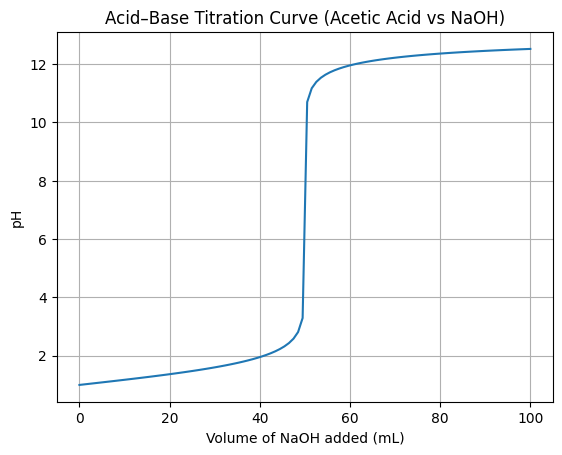

In [ ]:
volumes = np.linspace(0, 0.1, 100)  # 0–100 mL base added
pH_values = [titration_curve(V) for V in volumes]

plt.plot(volumes*1000, pH_values)
plt.xlabel("Volume of NaOH added (mL)")
plt.ylabel("pH")
plt.title("Acid–Base Titration Curve (Acetic Acid vs NaOH)")
plt.grid(True)
plt.show()


The `!` at the beginning of the command tells Colab to execute the command as a shell command rather than a Python command.